In [ ]:
import numpy as np #Проверка связи 2
import matplotlib.pyplot as plt
from T_method import LayeredStructure
from My_plotter import Style, Plotter
from scipy.optimize import minimize

In [12]:
st = Style()
ndf = 100 # кол-во точек по df
min_df = -0.5
max_df = 0.5
df_width = (max_df - min_df)*100 # ширина по df в процентах
points_per_m_percent = lambda m: int(ndf * m / df_width) # кол-во точек на m процентов по df
df = np.linspace(min_df, max_df, ndf) # относительный сдвиг частоты
def sigma(x, thres=0, k=3):
    return 1/(1+np.exp(-k*(x - thres)))
def penalty(x, thres=0, k=3, c=3):
    return c/k * np.log(1 + np.exp(-k*(x - thres)))

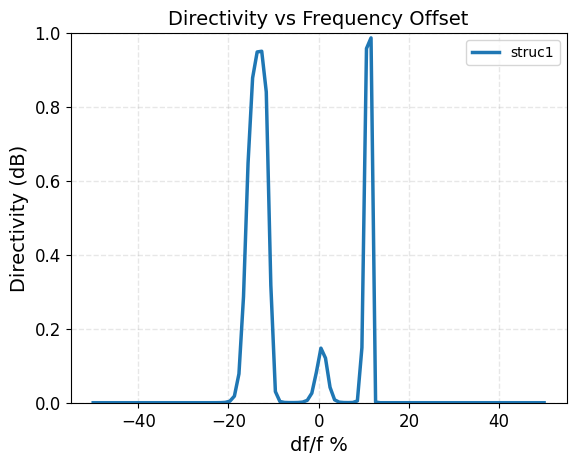

In [13]:

alpha1 = np.array([3, -1.2, 2.9, -1.2, 1])*1.4
beta1 = np.array([2.8, 0.75, 0.65, 0.6, 0.5])
structure1 = LayeredStructure(alpha1, beta=beta1)
dir1 = 10*np.log10(structure1.directivity(df))
dir1 = sigma(dir1, thres=15, k=3)
fig, ax = plt.subplots()
pl = Plotter(ax, st)
pl.plot(df*100, dir1, label='struc1')
pl.set_xlabel('df/f %')
pl.set_ylabel('Directivity (dB)')
pl.set_title('Directivity vs Frequency Offset')
pl.set_ylim((0, 1))
pl.finalize()
ax.axhline(18, color='gray', linestyle='--', alpha=0.5)
plt.show()


In [14]:
count = 0
def objective_function(params):
    global count
    n = len(params) // 2
    m_target = points_per_m_percent(25)  # 10% of df width
    alpha = np.array(params[:n])
    beta = np.array(params[n:])
    structure = LayeredStructure(alpha, beta=beta)
    directivity = 10*np.log10(structure.directivity(df))
    target_f = -np.inf
    for i in range(0, ndf-m_target):
        segment_i = directivity[i:i+m_target]
        target_f_i = np.sum(sigma(segment_i, thres=15, k=3) - penalty(segment_i, thres=15, k=3, c=0.3))
        if target_f_i > target_f:
            target_f = target_f_i
    print(f"Iteration {count}: target_f = {target_f/ndf*df_width:.4f}")
    count += 1
    return -target_f  # We want to maximize target_f, so we minimize the negative of it
bounds = [
    (0,  8.0), (-6.0, 0), (0, 7.0), (-6.0, 0), (0, 6.0),  # alpha
    (0.1,  7.0), ( 0.1, 1.0), ( 0.1, 1.0), ( 0.1, 1.0), ( 0.1, 1.0),  # beta
]
alpha0 = np.array([ 6.99999966, -1.71747606,  5.99983892, -1.51878485,  1.25619562])
beta0 = np.array([2.79551947, 0.83206359, 0.57820422, 0.61651286, 0.53884595])
initial_params = np.concatenate([alpha0, beta0])
print(objective_function(initial_params)/ndf*df_width)  # Check initial score


Iteration 0: target_f = 20.6618
-20.661771905838282


In [15]:
count = 0

res = minimize(
    objective_function,
    x0=initial_params,
    method="L-BFGS-B",
    bounds=bounds,
    options=dict(
        maxiter=50,     # максимум итераций L-BFGS-B
        maxfun=500,    # максимум вызовов objective (иногда ключ именно maxfun)
        gtol=1e-3,      # критерий по градиенту (важнее всего для L-BFGS-B)
        ftol=1e-9,      # критерий по изменению функции (может игнорироваться в старых)
        disp=True
    )
)
best_params = res.x
best_score = -res.fun  # because we minimized -J

print("Success:", res.success)
print("Message:", res.message)
print("Best score (sum of sigmoids):", best_score/ndf*df_width)
print("Best params:", best_params)


C:\Users\Michael\AppData\Local\Temp\ipykernel_9884\2433024844.py:3: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


Iteration 0: target_f = 20.6618
Iteration 1: target_f = 20.6618
Iteration 2: target_f = 20.6618
Iteration 3: target_f = 20.6618
Iteration 4: target_f = 20.6618
Iteration 5: target_f = 20.6618
Iteration 6: target_f = 20.6618
Iteration 7: target_f = 20.6618
Iteration 8: target_f = 20.6618
Iteration 9: target_f = 20.6618
Iteration 10: target_f = 20.6618
Iteration 11: target_f = -142.8549
Iteration 12: target_f = -142.8549
Iteration 13: target_f = -142.8549
Iteration 14: target_f = -142.8549
Iteration 15: target_f = -142.8549
Iteration 16: target_f = -142.8549
Iteration 17: target_f = -142.8549
Iteration 18: target_f = -142.8549
Iteration 19: target_f = -142.8549
Iteration 20: target_f = -142.8549
Iteration 21: target_f = -142.8549
Iteration 22: target_f = 4.9194
Iteration 23: target_f = 4.9194
Iteration 24: target_f = 4.9194
Iteration 25: target_f = 4.9194
Iteration 26: target_f = 4.9194
Iteration 27: target_f = 4.9194
Iteration 28: target_f = 4.9194
Iteration 29: target_f = 4.9194
Iterat

In [37]:
print("Optimized alpha:", repr(best_params[:5]))
print("Optimized beta:", repr(best_params[5:]))

Optimized alpha: array([ 5.99963771, -1.51291449,  4.73240322, -1.43160325,  1.34233082])
Optimized beta: array([2.76095422, 0.79126909, 0.63518713, 0.6       , 0.5       ])
